In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

# サンプルコーパス
text = "I love natural language processing and I love machine learning"

# 前処理
words = text.lower().split()
vocab = list(set(words))
word_to_ix = {word: i for i, word in enumerate(vocab)}
vocab_size = len(vocab)

# context window
window_size = 2

# training data作成
data = []
for i in range(window_size, len(words) - window_size):
    context = []
    for j in range(-window_size, window_size + 1):
        if j != 0:
            context.append(word_to_ix[words[i + j]])
    target = word_to_ix[words[i]]
    data.append((context, target))


class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear1 = nn.Linear(embedding_dim, 128)
        self.linear2 = nn.Linear(128, vocab_size)

    def forward(self, inputs):
        embeds = self.embeddings(inputs)
        embeds = torch.mean(embeds, dim=0)
        out = torch.relu(self.linear1(embeds))
        out = self.linear2(out)
        return out


embedding_dim = 10
model = CBOW(vocab_size, embedding_dim)

loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# training
for epoch in range(100):
    total_loss = 0

    for context, target in data:
        context_tensor = torch.tensor(context, dtype=torch.long)

        model.zero_grad()

        output = model(context_tensor)

        loss = loss_function(output.view(1, -1), torch.tensor([target]))
        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    if epoch % 20 == 0:
        print(f"epoch {epoch} loss {total_loss}")


# 学習された単語ベクトル
print("\nWord Embeddings")
for word, idx in word_to_ix.items():
    print(word, model.embeddings.weight[idx])

epoch 0 loss 12.769385576248169
epoch 20 loss 10.218775033950806
epoch 40 loss 8.322672843933105
epoch 60 loss 6.705383837223053
epoch 80 loss 5.409189134836197

Word Embeddings
language tensor([ 0.0417,  0.9050,  0.1081, -0.2113,  0.6344,  1.1082, -1.8295, -1.0043,
        -0.2920, -0.0477], grad_fn=<SelectBackward0>)
machine tensor([-2.2424,  1.0592,  0.2834, -0.6218,  1.3807,  1.1756,  1.4711,  0.3205,
        -0.2776,  0.7719], grad_fn=<SelectBackward0>)
natural tensor([ 0.6009, -1.0279,  0.0018, -0.7008,  0.3710, -0.8697,  0.8876,  1.1903,
        -0.5073,  1.4273], grad_fn=<SelectBackward0>)
i tensor([-1.1137,  0.1311, -0.3574, -1.1805, -0.1165, -0.1396,  0.7389,  0.8211,
         0.5481,  0.0105], grad_fn=<SelectBackward0>)
processing tensor([ 0.0562, -0.0268, -0.5483, -1.5143, -0.2529, -0.7705,  0.4602,  2.0241,
         0.9441,  0.1655], grad_fn=<SelectBackward0>)
learning tensor([-0.6222, -1.7580,  0.3444,  2.0942,  0.5830, -1.3552,  0.0511,  1.6023,
         1.0933,  1.1400]

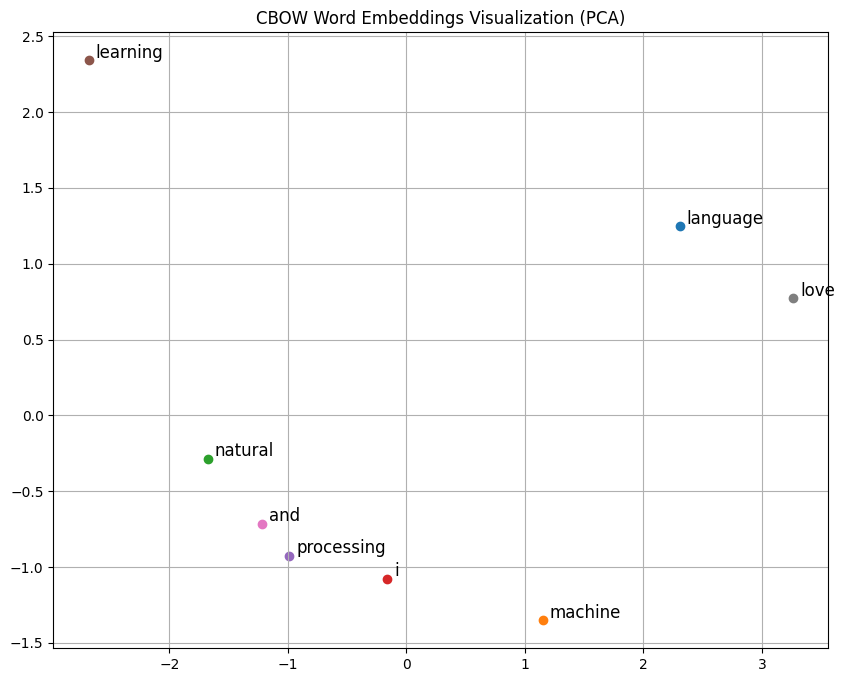

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. 重み行列（Embedding Layer）を取得
embeddings = model.embeddings.weight.detach().cpu().numpy()

# 2. PCAで10次元から2次元に圧縮
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 3. プロット
plt.figure(figsize=(10, 8))
for i, word in enumerate(vocab):
    x, y = reduced_embeddings[i]
    plt.scatter(x, y)
    plt.annotate(word, (x, y), xytext=(5, 2), textcoords='offset points', fontsize=12)

plt.title('CBOW Word Embeddings Visualization (PCA)')
plt.grid(True)
plt.show()

In [5]:
import torch
import torch.nn.functional as F

# embedding matrix取得
embeddings = model.embeddings.weight.detach()

# 単語 → index
word_to_ix = word_to_ix
ix_to_word = {v: k for k, v in word_to_ix.items()}


def cosine_similarity(vec1, vec2):
    return F.cosine_similarity(vec1.unsqueeze(0), vec2.unsqueeze(0)).item()


def most_similar(word, top_k=3):
    if word not in word_to_ix:
        print("word not in vocabulary")
        return

    word_idx = word_to_ix[word]
    word_vec = embeddings[word_idx]

    similarities = []

    for idx, vec in enumerate(embeddings):
        if idx == word_idx:
            continue

        sim = cosine_similarity(word_vec, vec)
        similarities.append((ix_to_word[idx], sim))

    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:top_k]


print("Similar words to 'i':")
print(most_similar("i"))

print("\nSimilar words to 'machine':")
print(most_similar("machine"))

Similar words to 'i':
[('processing', 0.7547917366027832), ('machine', 0.556310772895813), ('natural', 0.2615177035331726)]

Similar words to 'machine':
[('i', 0.556310772895813), ('love', 0.23061510920524597), ('processing', 0.05444828420877457)]
